In [1]:
import os
import glob
import sys

import itertools

import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm as tqdm_auto
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import pytorch_lightning as pl

from IPython.display import clear_output

In [2]:
# Load all models
from optimus5 import Optimus5PrimeOriginal
from optimus5_25 import Optimus5Prime25
from mttrans import RL_gru
from framepool import FramePool
from dream_wrappers import DreamRNNFacade, DreamAttnFacade

In [3]:
sys.path.append("../../predictor/model/")
import utrdata_cl as utrdata
from pl_regressor import RNARegressor
from legnet_classifier import LegNetClassifier

In [4]:
utr_type = "utr3"
seqsize = 50 if utr_type == "utr5" else 240

## Loading data

In [5]:
PATH_FROM = f"../../predictor/library2/{utr_type.upper()}_zscores_2024-06-04.csv"
df = pd.read_csv(PATH_FROM)

In [6]:
num_classes = df["cell_type"].unique().shape[0]
num_classes

5

In [7]:
batch_size = 128

In [8]:
num_workers = 32

In [9]:
test_set = utrdata.UTRData(
    df=df,
    predict_cols=["mass_center"],
    construct_type=utr_type,
    features=("sequence", "conditions"),
    augment=False,
    augment_test_time=False,
    augment_kws=dict(
        extend_left=0,
        extend_right=0,
        shift_left=0,
        shift_right=0,
        revcomp=False,
    ),
)
dl_test = DataLoader(
    test_set,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=False
)

parade_test_set = utrdata.UTRData(
    df=df,
    construct_type=utr_type,
    features=("sequence", "positional", "conditions"),
    augment=False,
    augment_test_time=False,
    augment_kws=dict(
        extend_left=0,
        extend_right=0,
        shift_left=0,
        shift_right=0,
        revcomp=False,
    ),
)
parade_dl_test = DataLoader(
    parade_test_set,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=False
)

### Loading models

In [10]:
legnet_checkpoint = glob.glob(f"../../predictor/regression_multiple/saved_models/model-{utr_type}*.ckpt")[0]
model_checkpoints = {os.path.basename(os.path.dirname(path)): path for path in glob.glob(f"./saved_models/{utr_type}/*/*.ckpt")}
model_checkpoints

{'DreamAttnFacade': './saved_models/utr3/DreamAttnFacade/epoch=3-step=17052.ckpt',
 'DreamRNNFacade': './saved_models/utr3/DreamRNNFacade/epoch=27-step=119364.ckpt',
 'Optimus5PrimeOriginal': './saved_models/utr3/Optimus5PrimeOriginal/epoch=9-step=10650.ckpt',
 'FramePool': './saved_models/utr3/FramePool/epoch=7-step=8520.ckpt',
 'Optimus5Prime25': './saved_models/utr3/Optimus5Prime25/epoch=9-step=10650.ckpt',
 'RL_gru': './saved_models/utr3/RL_gru/epoch=99-step=426300.ckpt'}

In [11]:
models = dict()
for model_name, ckpt_path in model_checkpoints.items():
    ckpt = torch.load(ckpt_path)
    loaded_model = RNARegressor(**ckpt["hyper_parameters"])
    loaded_model.load_state_dict(ckpt["state_dict"])
    models[model_name] = loaded_model
legnet_ckpt = torch.load(legnet_checkpoint)
legnet_model = RNARegressor(**legnet_ckpt["hyper_parameters"])
legnet_model.load_state_dict(legnet_ckpt["state_dict"])

<All keys matched successfully>

In [12]:
progressbar_callback = pl.callbacks.TQDMProgressBar(refresh_rate=0.5)
trainer = pl.Trainer(
    callbacks=[progressbar_callback],
    logger=False,
    accelerator="gpu",
    devices=[0],
    deterministic=True,
    num_sanity_val_steps=0,
)
result_df = df[["seq", "cell_type", "mass_center"]].copy()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [13]:
for model_name, model_instance in models.items():
    print(model_name)
    prediction = trainer.predict(model=model_instance, dataloaders=dl_test)
    test_pred, test_real = zip(*prediction)
    test_pred = torch.concat(test_pred).numpy()
    # test_real = torch.concat(test_real).numpy()
    result_df[model_name] = test_pred[:, 0]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


DreamAttnFacade


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting: 0it [00:00, ?it/s]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


...

Optimus5Prime25


Predicting: 0it [00:00, ?it/s]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


RL_gru


Predicting: 0it [00:00, ?it/s]

In [14]:
print("LegNetClassifier")
prediction = trainer.predict(model=legnet_model, dataloaders=parade_dl_test)
test_pred, test_real = zip(*prediction)
test_pred = torch.concat(test_pred).numpy()
# test_real = torch.concat(test_real).numpy()
result_df["LegNetClassifier"] = test_pred[:, 1]
result_df["LegNetClassifier_delta"] = test_pred[:, 0]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


LegNetClassifier


Predicting: 0it [00:00, ?it/s]

In [15]:
result_df_r = pd.concat({"pred_mass_center": result_df.drop(["seq", "cell_type", "mass_center"], axis=1)}, axis=1)
for i, col in enumerate(["seq", "cell_type", "mass_center"]):
    result_df_r.insert(i, col, result_df[col])
result_df_r

seq cell_type  \
                                                                     
0      AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...        c1   
1      AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...       c17   
2      AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...        c2   
3      AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...        c4   
4      AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...        c6   
...                                                  ...       ...   
28370  TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...        c1   
28371  TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...       c17   
28372  TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...        c2   
28373  TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...        c4   
28374  TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...        c6   

      mass_center pred_mass_center                                       \
                   DreamAttnFacade DreamRNNFacade Optimus5PrimeOriginal   
0        2.396253         2.824792       2.588290              2.852733   
1        2.234294         2.173720       2.021487              2.642889   
2        2.497488         2.256605       2.315141              2.542298   
3        2.363411         2.252658       2.504411              2.602017   
4        2.415970         2.273190       2.206998              2.709597   
...           ...              ...            ...                   ...   
28370    2.217097         2.403796       2.149632              2.360600   
28371    2.803389         2.424888       2.228660              2.308703   
28372    1.606870         2.219263       2.042708              2.238843   
28373    2.105108         2.515988       2.505737              2.441900   
28374    2.229508         2.315478       2.192856              2.374155   

                                                            \
      FramePool Optimus5Prime25    RL_gru LegNetClassifier   
0      2.714762        2.848827  2.907354         2.277333   
1      2.455954        2.319590  2.549616         2.070687   
2      2.483404        2.288353  2.463407         2.096115   
3      2.496463        2.358430  2.492215         2.057427   
4      2.510754        2.318240  2.473324         2.293080   
...         ...             ...       ...              ...   
28370  2.193401        2.213357  2.390558         2.354973   
28371  2.161308        2.226154  2.395729         2.522218   
28372  2.117383        2.089930  2.285138         2.379673   
28373  2.322005        2.341829  2.455994         2.535287   
28374  2.158476        2.185961  2.405237         2.526350   

                              
      LegNetClassifier_delta  
0                   0.201250  
1                  -0.035715  
2                   0.006151  
3                   0.000221  
4                  -0.011891  
...                      ...  
28370              -0.138595  
28371               0.045523  
28372              -0.052481  
28373               0.060691  
28374               0.059909  

[28375 rows x 11 columns]

In [16]:
result_df_r.to_parquet(f"benchmark_preds_{utr_type}_lib2.parquet")

In [17]:
correlations = result_df.groupby("cell_type")[["mass_center"] + list(models.keys()) + ["LegNetClassifier"]].corr()["mass_center"].unstack(0).drop("mass_center", axis=0)
correlations["mean"] = result_df.groupby("seq")[["mass_center"] + list(models.keys()) + ["LegNetClassifier"]].mean().corr()["mass_center"].drop("mass_center")
correlations

cell_type,c1,c17,c2,c4,c6,mean
DreamAttnFacade,0.572519,0.475364,0.627696,0.538192,0.552344,0.639795
DreamRNNFacade,0.325558,0.604950,0.598030,0.642600,0.636127,0.659423
Optimus5PrimeOriginal,0.501409,0.491408,0.573129,0.536380,0.509803,0.592457
FramePool,0.498329,0.484810,0.569874,0.519399,0.490190,0.596831
Optimus5Prime25,0.528482,0.522103,0.586183,0.571684,0.544194,0.630240
RL_gru,0.517439,0.450692,0.597626,0.485639,0.460268,0.591103
LegNetClassifier,0.669872,0.649836,0.681765,0.674730,0.696651,0.767333


<Axes: ylabel='cell_type'>

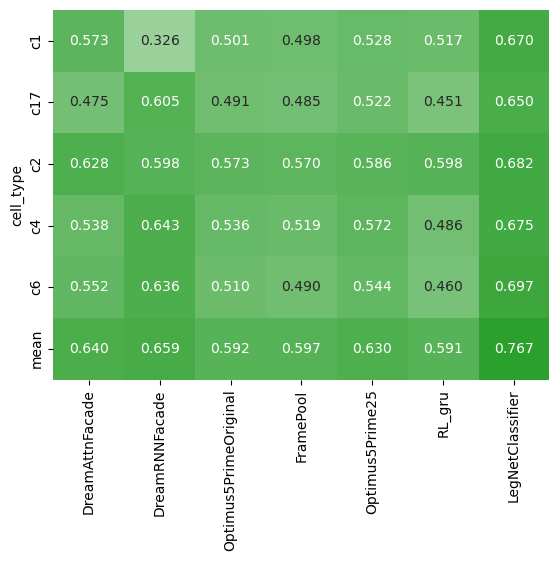

In [18]:
sns.heatmap(correlations.T, cmap=sns.color_palette("light:C2", n_colors=1000, as_cmap=True), vmin=0,
            annot=True, fmt=".3f", cbar=False)

In [19]:
correlations.mean(axis=1).sort_values(ascending=False)

LegNetClassifier         0.690031
DreamRNNFacade           0.577781
DreamAttnFacade          0.567652
Optimus5Prime25          0.563814
Optimus5PrimeOriginal    0.534098
FramePool                0.526572
RL_gru                   0.517128
dtype: float64

In [20]:
list(zip(correlations.columns, correlations.index[correlations.values.argmax(axis=0)]))

[('c1', 'LegNetClassifier'),
 ('c17', 'LegNetClassifier'),
 ('c2', 'LegNetClassifier'),
 ('c4', 'LegNetClassifier'),
 ('c6', 'LegNetClassifier'),
 ('mean', 'LegNetClassifier')]

---